# AZTEC for YT
This notebook loads a merged capacity traffic NumPy file and runs Block-1 training from the AZTEC+ framework.

Adjust the parameters below (lookback, delay, PHI, GAMMA, epochs) to suit your experiment.

In [1]:
import os
import sys
import numpy as np
from pprint import pprint
import tqdm
print('Python version:', sys.version.splitlines()[0])
print('Numpy version:', np.__version__)

Python version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
Numpy version: 1.22.4


In [19]:
import pandas as pd

# Path to the merged YT capacity traffic dataset
npy_path = '/home/jupyter-salcala/Distributed_learning/dataset/split_session/predictions/real_yt_data_capacity_traffic/kansaas_ready/merged_capacity_traffic.npy'

bordeaux = np.load(npy_path)
if bordeaux.ndim == 1:
    bordeaux = bordeaux.reshape(-1, 1)

# Clean missing / infinite values before scaling so the model does not train on NaNs.
raw_nan_count = np.isnan(bordeaux).sum()
raw_inf_count = np.isinf(bordeaux).sum()
if raw_nan_count or raw_inf_count:
    print(f'Raw data contains {raw_nan_count} NaNs and {raw_inf_count} inf values; interpolating them.')
    bordeaux = pd.DataFrame(bordeaux).replace([np.inf, -np.inf], np.nan)
    bordeaux = bordeaux.interpolate(axis=0, limit_direction='both').bfill().ffill().to_numpy()

print('Loaded dataset shape:', bordeaux.shape)
print('NaNs after cleanup:', np.isnan(bordeaux).sum())

# Use 80% of the series for training and 20% for testing
XTRAIN = round(len(bordeaux) * 0.8)
print('XTRAIN:', XTRAIN)

Raw data contains 9 NaNs and 0 inf values; interpolating them.
Loaded dataset shape: (63000, 1)
NaNs after cleanup: 0
XTRAIN: 50400


In [3]:
from tensorflow import keras
import tensorflow as tf
from keras import backend as K
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import time
import pickle

The next cells define the dataset split, LSTM/CNN builders, training loop, and prediction routine for the merged YT capacity traffic series.

In [20]:
# Model and forecasting parameters
LOOKBACK = 6   # history length used as input to the network
DELAY = 6      # forecast horizon
PHI = 10       # negative slope of the loss function
GAMMA = 2      # positive slope of the loss function
NUM_SERV = bordeaux.shape[-1]
EPOCHS = 300
B = 100        # number of Monte Carlo outputs

# Split and normalize data
minmaxscaler = MinMaxScaler()
x_train = bordeaux[:XTRAIN]
x_test = bordeaux[XTRAIN:]

x_train_norm = tf.convert_to_tensor(minmaxscaler.fit_transform(x_train), dtype=tf.float32)
x_test_norm = tf.convert_to_tensor(minmaxscaler.transform(x_test), dtype=tf.float32)

# Build input, target, and test datasets
input_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_train_norm[:-DELAY],
    None,
    sequence_length=LOOKBACK,
    sequence_stride=DELAY
)

target_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_train_norm[LOOKBACK:],
    None,
    sequence_length=DELAY,
    sequence_stride=DELAY
)

test_dataset = keras.preprocessing.timeseries_dataset_from_array(
    x_test_norm[:-DELAY],
    None,
    sequence_length=LOOKBACK,
    sequence_stride=DELAY,
    batch_size=128
)

print('Train tensor:', x_train_norm.shape)
print('Test tensor:', x_test_norm.shape)
print('Input batches:', len(input_dataset))
print('Target batches:', len(target_dataset))
print('Test batches:', len(test_dataset))

Train tensor: (50400, 1)
Test tensor: (12600, 1)
Input batches: 66
Target batches: 66
Test batches: 17


In [21]:
def cost_func(y_true, y_pred, reduction='none'):
    slope = PHI
    gamma = GAMMA
    delta_x = 0.05
    forecast_delay = DELAY

    y_pred = tf.expand_dims(y_pred, axis=1)
    y_pred = tf.tile(y_pred, (1, forecast_delay, 1))
    cost = y_pred - y_true - delta_x
    pen_positive = gamma * cost
    pen_negative = slope * cost
    cost = tf.where(cost > 0, pen_positive, cost)
    cost = tf.where(cost <= 0, pen_negative, cost)
    cost = tf.abs(cost)
    cost = K.sum(K.sum(cost, axis=-1), axis=-1)
    return cost


def make_model_lstm(input_shape, lookback, num_services, phi=PHI):
    inputs = Input(shape=(lookback, num_services))
    model = layers.LSTM(128)(inputs)
    model = layers.Dropout(0.3)(model, training=True)
    model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    output = layers.Dense(num_services)(model)
    model = Model(inputs, output)
    return model


def make_model_cnn(input_shape, lookback, num_services):
    inputs = Input(shape=(lookback, num_services))
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    model = layers.Conv1D(32, 3, activation='relu', padding='same')(model)
    model = layers.Flatten()(model)
    model = layers.Dense(64, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    model = layers.Dense(32, activation='relu')(model)
    model = layers.Dropout(0.3)(model, training=True)
    output = layers.Dense(num_services)(model)
    model = Model(inputs, output)
    return model

model = make_model_lstm(x_train_norm.shape, LOOKBACK, NUM_SERV)
model.summary()
optimizer = Adam(learning_rate=0.0005)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 6, 1)]            0         
                                                                 
 lstm_1 (LSTM)               (None, 128)               66560     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 74,881
Trainable params: 74,881
Non-trainable

In [6]:
for epoch in tqdm.tqdm(range(EPOCHS)):
    for step, (x_batch_train, y_batch_train) in enumerate(zip(input_dataset, target_dataset)):
        with tf.GradientTape() as tape:
            prediction = model(x_batch_train, training=True)
            loss_value = cost_func(y_batch_train, prediction)
        grads = tape.gradient(loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

print('Training finished')

  0%|          | 0/300 [00:00<?, ?it/s]2026-05-29 18:43:04.804880: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8800
2026-05-29 18:43:07.996446: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
100%|██████████| 300/300 [04:25<00:00,  1.13it/s]

Training finished


0 (128, 6, 1)
1 (128, 6, 1)
2 (128, 6, 1)
3 (128, 6, 1)
4 (128, 6, 1)
5 (128, 6, 1)
6 (128, 6, 1)
7 (128, 6, 1)
8 (128, 6, 1)
9 (128, 6, 1)
10 (128, 6, 1)
11 (128, 6, 1)
12 (128, 6, 1)
13 (128, 6, 1)
14 (128, 6, 1)
15 (128, 6, 1)
16 (51, 6, 1)
Time taken for the forecast in seconds: 78.35576367378235


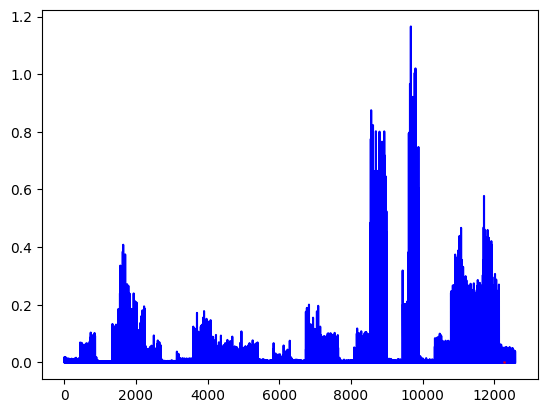

In [7]:
start = time.time()

load_forecasted = np.zeros((int(x_test_norm.shape[0] / DELAY), NUM_SERV, B))
for idx, inputs in enumerate(test_dataset):
    print(idx, inputs.shape)
    for i in range(B):
        if inputs.shape[0] == 128:
            load_forecasted[idx * 128: (idx + 1) * 128, :, i] = model.predict(inputs, verbose=0)
        else:
            load_forecasted[-inputs.shape[0]:, :, i] = model.predict(inputs, verbose=0)

load_forecasted = np.repeat(load_forecasted, DELAY, axis=0)
end = time.time()
print('Time taken for the forecast in seconds:', end - start)

for service in range(min(NUM_SERV, 5)):
    plt.figure()
    plt.plot(x_test_norm[LOOKBACK:-DELAY, service], 'b')
    plt.plot(load_forecasted[:, service].mean(axis=-1), 'r')
plt.show()

np.save('./aztec_for_YT_forecast.npy', load_forecasted)
pickle.dump(minmaxscaler, open('./aztec_for_YT_minmaxscaler.pkl', 'wb'))

In [15]:
print(load_forecasted)

[[[nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]]

 ...

 [[nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]]]


In [12]:
load_forecasted.mean(axis=-1).shape

(12600, 1)

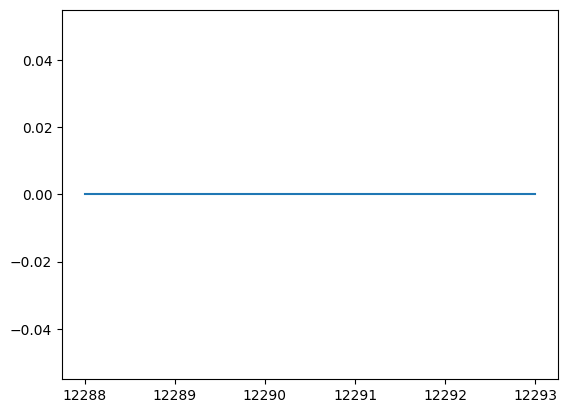

In [13]:
plt.plot(load_forecasted.mean(axis=-1))

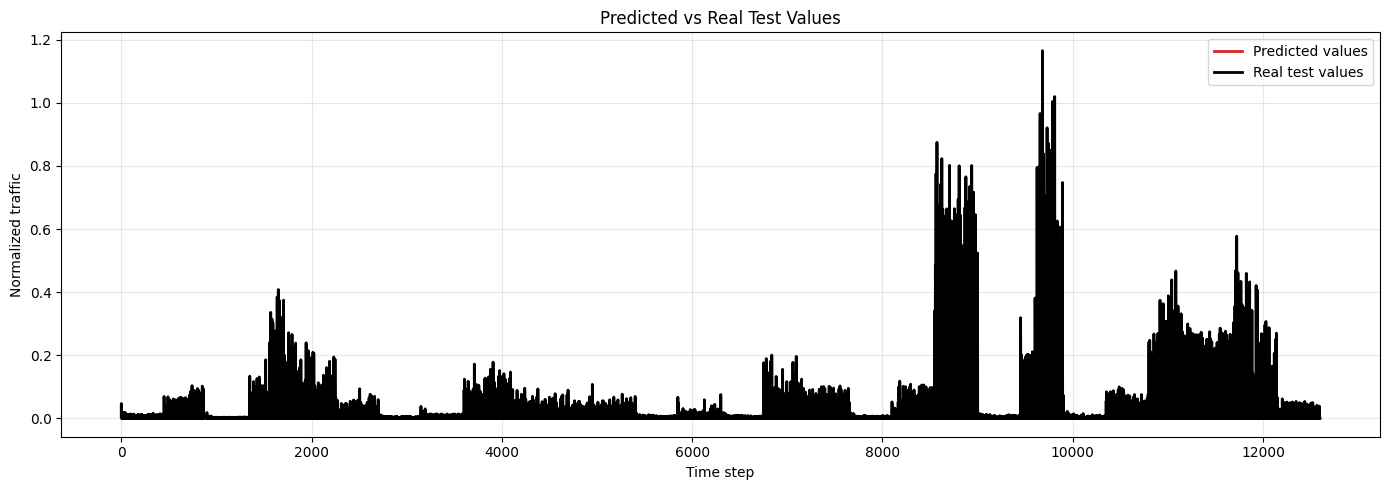

In [10]:
# Compare predicted vs real test values
real_test = x_test_norm.numpy()
pred_test = load_forecasted.mean(axis=-1)

if real_test.ndim == 2 and real_test.shape[1] == 1:
    real_test = real_test[:, 0]
if pred_test.ndim == 2 and pred_test.shape[1] == 1:
    pred_test = pred_test[:, 0]

n = min(len(real_test), len(pred_test))

plt.figure(figsize=(14, 5))
plt.plot(pred_test[:n], label='Predicted values', linewidth=2, color='tab:red')
plt.plot(real_test[:n], label='Real test values', linewidth=2, color='black')
plt.title('Predicted vs Real Test Values')
plt.xlabel('Time step')
plt.ylabel('Normalized traffic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# Diagnostics for NaN inference
first_test_batch = next(iter(test_dataset))
if isinstance(first_test_batch, tuple):
    first_test_batch = first_test_batch[0]

first_pred = model.predict(first_test_batch, verbose=0)

print('x_train_norm has NaN:', np.isnan(x_train_norm.numpy()).any())
print('x_test_norm has NaN:', np.isnan(x_test_norm.numpy()).any())
print('first test batch has NaN:', np.isnan(first_test_batch.numpy()).any())
print('model prediction has NaN:', np.isnan(first_pred).any())
print('model prediction min/max:', np.nanmin(first_pred), np.nanmax(first_pred))
print('first batch min/max:', np.nanmin(first_test_batch.numpy()), np.nanmax(first_test_batch.numpy()))

x_train_norm has NaN: False
x_test_norm has NaN: False
first test batch has NaN: False
model prediction has NaN: False
model prediction min/max: -0.0014673437 0.0017105638
first batch min/max: 0.0 0.10371367
